In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from neural_network.utils import build_covariance_matrix
from neural_network.trainer import HestonTrainer
from neural_network.config import HestonParams, HestonParamsMulti, ModelConfig
from neural_network.payoff import Put, PutProductMultipleAssets

In [2]:
exercise_type = "american"

n_assets = 2

S0 = 1.0   # Initial stock price
K = 1.0    # Strike price
T = 1.0      # Time to maturity
r = 0.05     # Risk-free rate
kappa = 2.0  # Mean reversion rate
theta = 0.04 # Long-term variance
sigma_bar = 0.3  # Volatility of variance
v0 = 0.04    # Initial variance

sigma = np.array([0.2, 0.25])  # Volatility of each asset

# Correlation matrix
rho_asset = 0.5
Sigma = np.full((n_assets, n_assets), rho_asset)
np.fill_diagonal(Sigma, 1.0)

rho_cross = [0.3, 0.4]  # Correlation between stock price and variance for each asset

S_min = 0.0
V_min = 0.05
S_max = 3 * S0
V_max = 5 * v0

params = HestonParamsMulti(
    n_assets=n_assets, S0=S0, v0=v0, r=r,
    kappa=kappa, theta=theta, sigma_bar=sigma_bar, sigma=sigma, Sigma=Sigma, rho=rho_cross, K=K, T=T,
    S_min=S_min, S_max=S_max, V_min=V_min, V_max=V_max
)


In [3]:
model_config = ModelConfig(
    input_size=n_assets + 2, # Stock prices + variance + time
    hidden_sizes=[64, 128, 128, 64],
    output_size=1,
    activation=nn.ReLU(),
    learning_rate=1e-3
)

payoff = PutProductMultipleAssets()

In [4]:
heston_trainer = HestonTrainer(model_config, params, payoff, exercise_type, seed=42)

Iteration 0, Loss: 4.7528605461120605
Iteration 100, Loss: 0.059838779270648956
Iteration 200, Loss: 0.03738033026456833
Iteration 300, Loss: 0.029557831585407257
Iteration 400, Loss: 0.017951425164937973
Iteration 500, Loss: 0.016360826790332794
Iteration 600, Loss: 0.01568039320409298
Iteration 700, Loss: 0.014223288744688034
Iteration 800, Loss: 0.015434544533491135
Iteration 900, Loss: 0.010931459255516529
Iteration 1000, Loss: 0.018059324473142624
Iteration 1100, Loss: 0.008207211270928383
Early stopping at epoch 1167


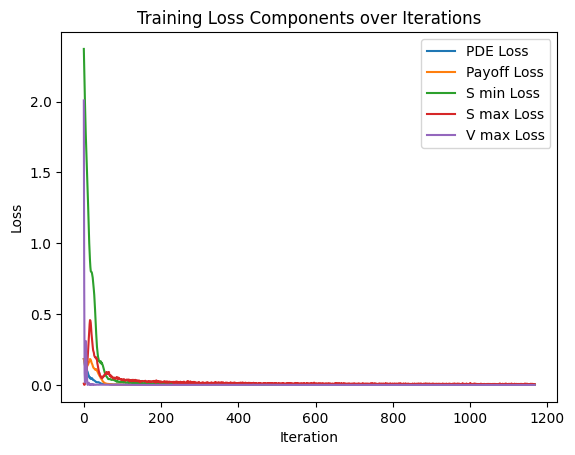

In [5]:
heston_trainer.train(batch_size=1024, epochs=10000, tol=1e-7)
heston_trainer.plot_losses_detailed()

In [10]:
S1 = np.linspace(S_min, S_max, 100)
S2 = np.linspace(S_min, S_max, 100)

V = v0

# Create a grid of stock prices
S1_grid, S2_grid = np.meshgrid(S1, S2)
S_grid = np.stack([S1_grid, S2_grid], axis=-1).reshape(-1, 2)
t = np.zeros((S_grid.shape[0], 1))  # Time to maturity is 0 at maturity
with torch.no_grad():
    model = heston_trainer.model
    model.eval()
    S_tensor = torch.tensor(S_grid, dtype=torch.float32)
    t_tensor = torch.tensor(t, dtype=torch.float32)
    V_tensor = torch.tensor([[V]], dtype=torch.float32).repeat(S_tensor.shape[0], 1)
    payoffs = model(t_tensor, S_tensor, V_tensor).numpy().reshape(100, 100)

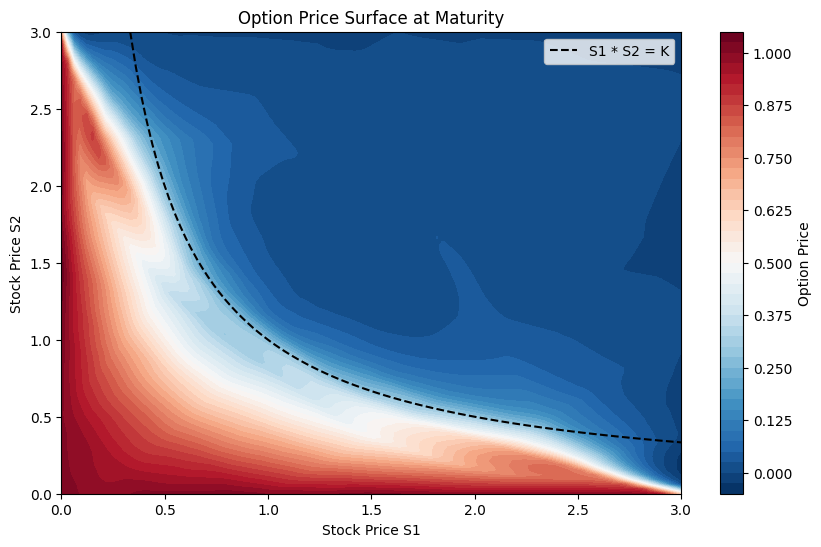

In [22]:
Xs = np.linspace(K / S_max, S_max, 100)
Ys = K / Xs

plt.figure(figsize=(10, 6))
plt.contourf(S1_grid, S2_grid, payoffs, levels=50, cmap='RdBu_r')
plt.colorbar(label='Option Price')
plt.plot(Xs, Ys, color='black', linestyle='--', label='S1 * S2 = K')
plt.xlabel('Stock Price S1')
plt.ylabel('Stock Price S2')
plt.title('Option Price Surface at Maturity')
plt.legend()
plt.show()


## Reduce to 1D case

In [ ]:
A = np.sum(np.square(sigma))
b = Sigma.T @ sigma
B = np.sum(np.square(b))



0.228125
